#🚢 Titanic Survival Prediction
## End-to-End Machine Learning Classification Project

---

**Author:** Akshaya Vasireddi
**Date:** June 2025  
**Tools:** Python | Pandas | Scikit-learn | Matplotlib | Seaborn  
**Dataset:** Titanic Passenger Data (891 records, 12 features)  

---

### 🎯 Project Objective
Predict whether a passenger survived the Titanic disaster using machine learning classification models, based on features such as age, gender, passenger class, and fare.

### 📌 Workflow
1. Exploratory Data Analysis (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Model Training & Evaluation
5. Hyperparameter Tuning
6. Final Prediction *System*



---
## 📦 Section 1: Importing Libraries
> Loading all required Python libraries for data manipulation, visualization, and machine learning.

In [ ]:
# ============================================================
# LIBRARY IMPORTS
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Machine Learning - Evaluation
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Section 2: Loading the Dataset
> Loading the Titanic dataset and performing an initial inspection to understand its structure, size, and contents.

In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

# Load the dataset
df = pd.read_csv('Titanic-Dataset.xls')

# Confirm it loaded correctly
print(f"✅ Dataset loaded successfully!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
📐 Shape: 891 rows × 12 columns


In [ ]:
# ============================================================
# FIRST LOOK AT THE DATA
# ============================================================

print("=" * 60)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 60)
df.head()

FIRST 5 ROWS OF THE DATASET


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("=" * 60)
print("LAST 5 ROWS OF THE DATASET")
print("=" * 60)
df.tail()

LAST 5 ROWS OF THE DATASET


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
print(f"  Rows    (passengers) : {df.shape[0]}")
print(f"  Columns (features)   : {df.shape[1]}")

DATASET DIMENSIONS
  Rows    (passengers) : 891
  Columns (features)   : 12


In [ ]:
print("=" * 60)
print("COLUMN NAMES")
print("=" * 60)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")

COLUMN NAMES
  01. PassengerId
  02. Survived
  03. Pclass
  04. Name
  05. Sex
  06. Age
  07. SibSp
  08. Parch
  09. Ticket
  10. Fare
  11. Cabin
  12. Embarked


In [ ]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print("=" * 60)
print("STATISTICAL SUMMARY — NUMERICAL COLUMNS")
print("=" * 60)
df.describe().round(2)

STATISTICAL SUMMARY — NUMERICAL COLUMNS


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [ ]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

MISSING VALUE SUMMARY
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


In [ ]:
# ============================================================
# CATEGORICAL COLUMNS OVERVIEW
# ============================================================

print("=" * 60)
print("CATEGORICAL COLUMNS — UNIQUE VALUES")
print("=" * 60)

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n📌 {col} ({df[col].nunique()} unique values)")
    print(f"   {df[col].value_counts().head(5).to_dict()}")

CATEGORICAL COLUMNS — UNIQUE VALUES

📌 Name (891 unique values)
   {'Dooley, Mr. Patrick': 1, 'Braund, Mr. Owen Harris': 1, 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)': 1, 'Heikkinen, Miss. Laina': 1, 'Futrelle, Mrs. Jacques Heath (Lily May Peel)': 1}

📌 Sex (2 unique values)
   {'male': 577, 'female': 314}

📌 Ticket (681 unique values)
   {'347082': 7, '1601': 7, 'CA. 2343': 7, '3101295': 6, 'CA 2144': 6}

📌 Cabin (147 unique values)
   {'G6': 4, 'C23 C25 C27': 4, 'B96 B98': 4, 'F2': 3, 'D': 3}

📌 Embarked (3 unique values)
   {'S': 644, 'C': 168, 'Q': 77}


In [ ]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

print("=" * 60)
print("SURVIVAL DISTRIBUTION (Target Variable)")
print("=" * 60)

survival_counts = df['Survived'].value_counts()
survival_pct = df['Survived'].value_counts(normalize=True) * 100

print(f"\n  Did not survive (0): {survival_counts[0]} passengers ({survival_pct[0]:.1f}%)")
print(f"  Survived       (1): {survival_counts[1]} passengers ({survival_pct[1]:.1f}%)")
print(f"\n  ⚠️  Class imbalance detected: {survival_pct[0]:.1f}% vs {survival_pct[1]:.1f}%")

SURVIVAL DISTRIBUTION (Target Variable)

  Did not survive (0): 549 passengers (61.6%)
  Survived       (1): 342 passengers (38.4%)

  ⚠️  Class imbalance detected: 61.6% vs 38.4%


---
## 📊 Section 3: Exploratory Data Analysis (EDA)
> Visualizing patterns, distributions, and relationships in the data to extract meaningful insights before building any model. Good EDA drives better feature engineering and model decisions.

In [ ]:
# ============================================================
# VISUALIZATION SETTINGS
# ============================================================

# Set global style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Visualization settings applied!")

✅ Visualization settings applied!


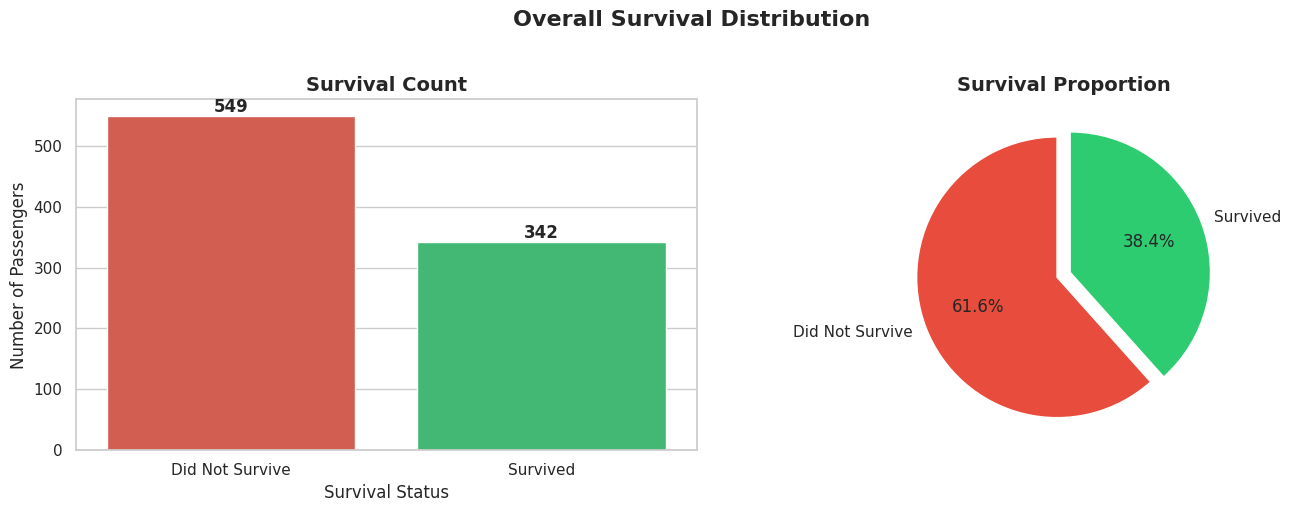


📌 Insight: Only 38.4% of passengers survived — a significant class imbalance.


In [ ]:
# ============================================================
# PLOT 1: SURVIVAL DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Count Plot ---
survival_labels = {0: 'Did Not Survive', 1: 'Survived'}
colors = ['#e74c3c', '#2ecc71']

ax1 = axes[0]
sns.countplot(x='Survived', data=df, palette=colors, ax=ax1)
ax1.set_title('Survival Count')
ax1.set_xlabel('Survival Status')
ax1.set_ylabel('Number of Passengers')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Did Not Survive', 'Survived'])

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- Right: Pie Chart ---
ax2 = axes[1]
survival_counts = df['Survived'].value_counts()
ax2.pie(survival_counts,
        labels=['Did Not Survive', 'Survived'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05))
ax2.set_title('Survival Proportion')

plt.suptitle('Overall Survival Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_survival_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Insight: Only 38.4% of passengers survived — a significant class imbalance.")

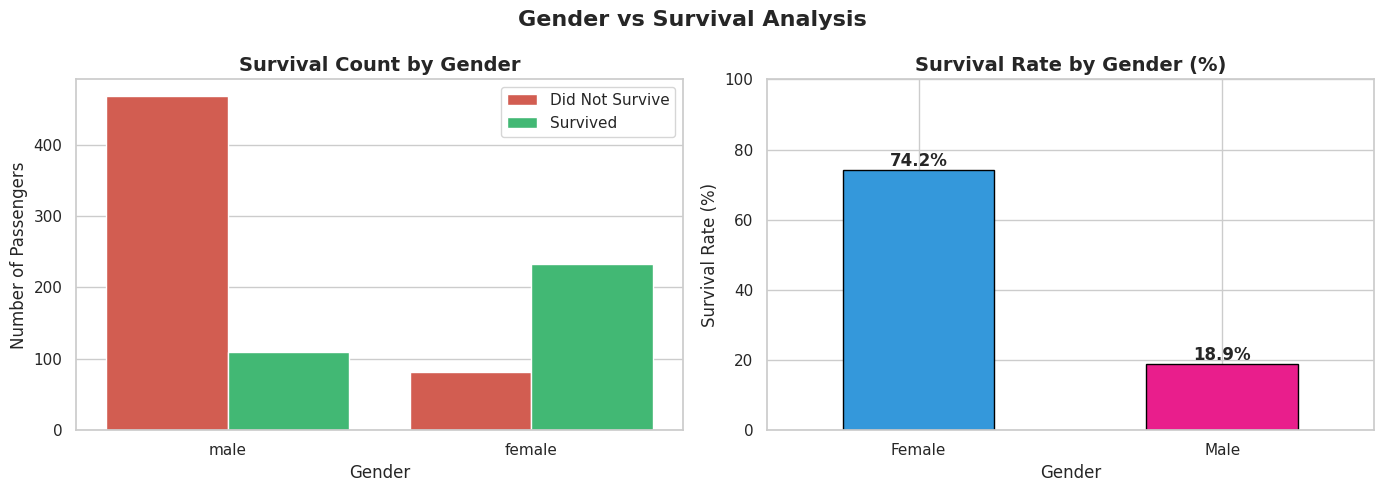


📌 Insight: Females had a 74.2% survival rate vs only 18.9% for males.
   This reflects the 'women and children first' evacuation protocol.


In [ ]:
# ============================================================
# PLOT 2: SURVIVAL BY GENDER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Grouped Count ---
ax1 = axes[0]
sns.countplot(x='Sex', hue='Survived', data=df,
              palette={0: '#e74c3c', 1: '#2ecc71'}, ax=ax1)
ax1.set_title('Survival Count by Gender')
ax1.set_xlabel('Gender')
ax1.set_ylabel('Number of Passengers')
ax1.legend(['Did Not Survive', 'Survived'])

# --- Right: Survival Rate ---
ax2 = axes[1]
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
survival_by_sex.plot(kind='bar', color=['#3498db', '#e91e8c'],
                     ax=ax2, edgecolor='black', width=0.5)
ax2.set_title('Survival Rate by Gender (%)')
ax2.set_xlabel('Gender')
ax2.set_ylabel('Survival Rate (%)')
ax2.set_xticklabels(['Female', 'Male'], rotation=0)
ax2.set_ylim(0, 100)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('Gender vs Survival Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_gender_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Females had a 74.2% survival rate vs only 18.9% for males.")
print("   This reflects the 'women and children first' evacuation protocol.")

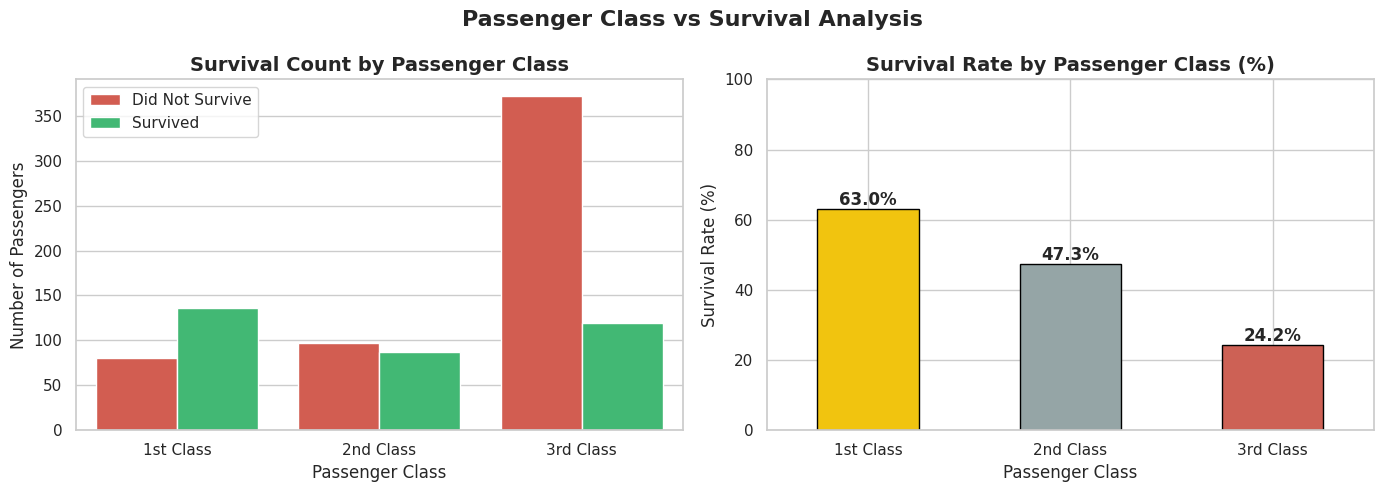


📌 Insight: 1st class: 63% survival | 2nd class: 47% | 3rd class: 24%
   Wealth and social class directly influenced access to lifeboats.


In [ ]:
# ============================================================
# PLOT 3: SURVIVAL BY PASSENGER CLASS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Grouped Count ---
ax1 = axes[0]
sns.countplot(x='Pclass', hue='Survived', data=df,
              palette={0: '#e74c3c', 1: '#2ecc71'}, ax=ax1)
ax1.set_title('Survival Count by Passenger Class')
ax1.set_xlabel('Passenger Class')
ax1.set_ylabel('Number of Passengers')
ax1.legend(['Did Not Survive', 'Survived'])
ax1.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# --- Right: Survival Rate ---
ax2 = axes[1]
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_class.plot(kind='bar',
                       color=['#f1c40f', '#95a5a6', '#cd6155'],
                       ax=ax2, edgecolor='black', width=0.5)
ax2.set_title('Survival Rate by Passenger Class (%)')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Survival Rate (%)')
ax2.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax2.set_ylim(0, 100)

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('Passenger Class vs Survival Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_class_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: 1st class: 63% survival | 2nd class: 47% | 3rd class: 24%")
print("   Wealth and social class directly influenced access to lifeboats.")

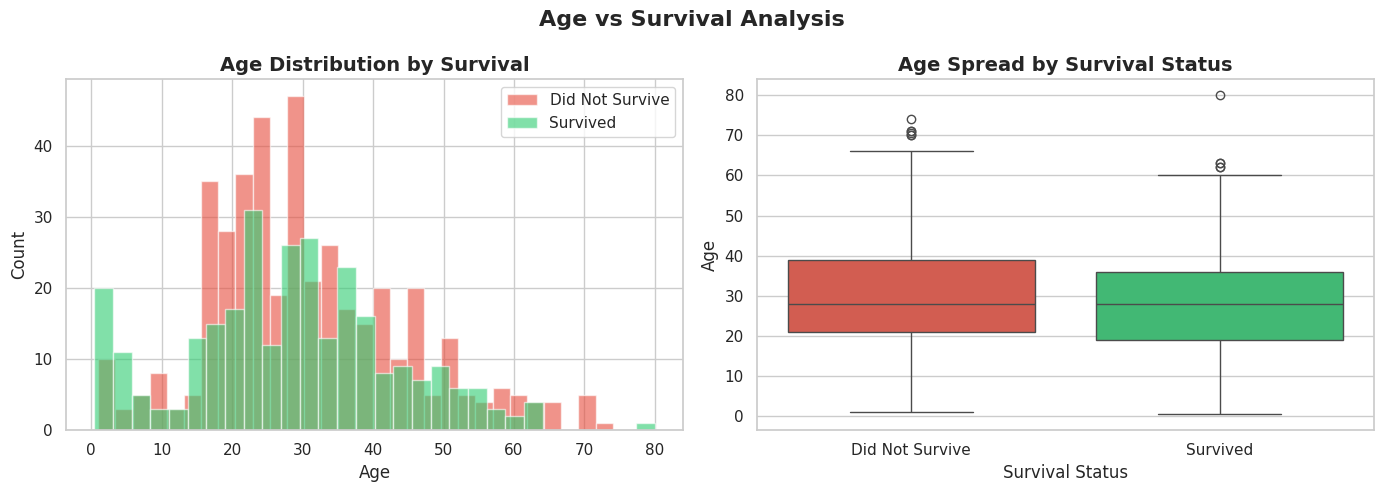


📌 Insight: Children (age < 10) had higher survival rates.
   The boxplot shows survivors were slightly younger on average.


In [ ]:
# ============================================================
# PLOT 4: AGE DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Age Distribution by Survival ---
ax1 = axes[0]
df[df['Survived'] == 0]['Age'].dropna().plot(kind='hist', bins=30,
    alpha=0.6, color='#e74c3c', label='Did Not Survive', ax=ax1)
df[df['Survived'] == 1]['Age'].dropna().plot(kind='hist', bins=30,
    alpha=0.6, color='#2ecc71', label='Survived', ax=ax1)
ax1.set_title('Age Distribution by Survival')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')
ax1.legend()

# --- Right: Boxplot
ax2 = axes[1]
sns.boxplot(x='Survived', y='Age', data=df,
            palette=['#e74c3c', '#2ecc71'], ax=ax2)
ax2.set_title('Age Spread by Survival Status')
ax2.set_xlabel('Survival Status')
ax2.set_ylabel('Age')
ax2.set_xticklabels(['Did Not Survive', 'Survived'])

plt.suptitle('Age vs Survival Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_age_survival.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Children (age < 10) had higher survival rates.")
print("   The boxplot shows survivors were slightly younger on average.")

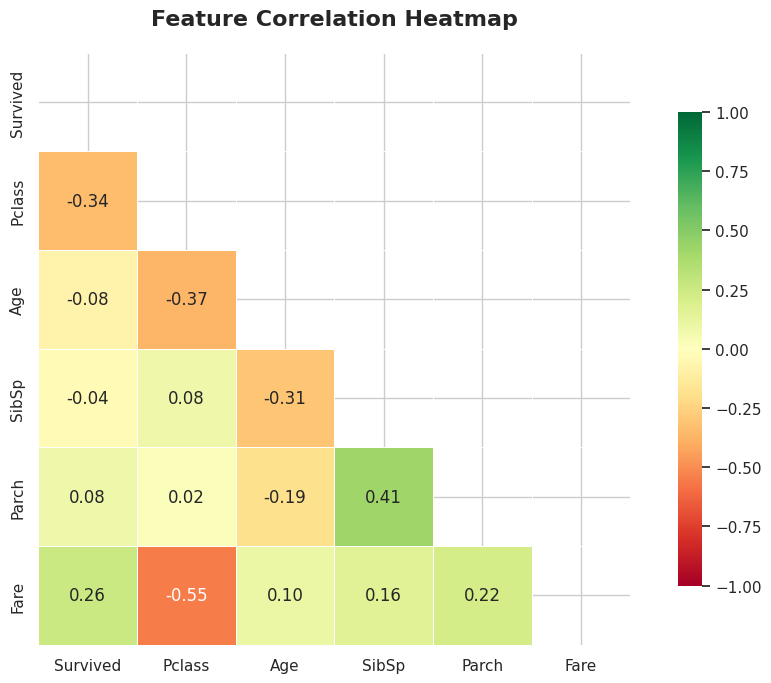


📌 Key Correlations with Survival:
   • Pclass  : -0.34  (higher class number = lower survival)
   • Fare    : +0.26  (higher fare = more likely to survive)
   • Age     : -0.08  (weak negative — older slightly less likely)
   • SibSp   : -0.04  (very weak)


In [ ]:
# ============================================================
# PLOT 5: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

# Select only numerical columns
numerical_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            mask=mask,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plot5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Key Correlations with Survival:")
print("   • Pclass  : -0.34  (higher class number = lower survival)")
print("   • Fare    : +0.26  (higher fare = more likely to survive)")
print("   • Age     : -0.08  (weak negative — older slightly less likely)")
print("   • SibSp   : -0.04  (very weak)")

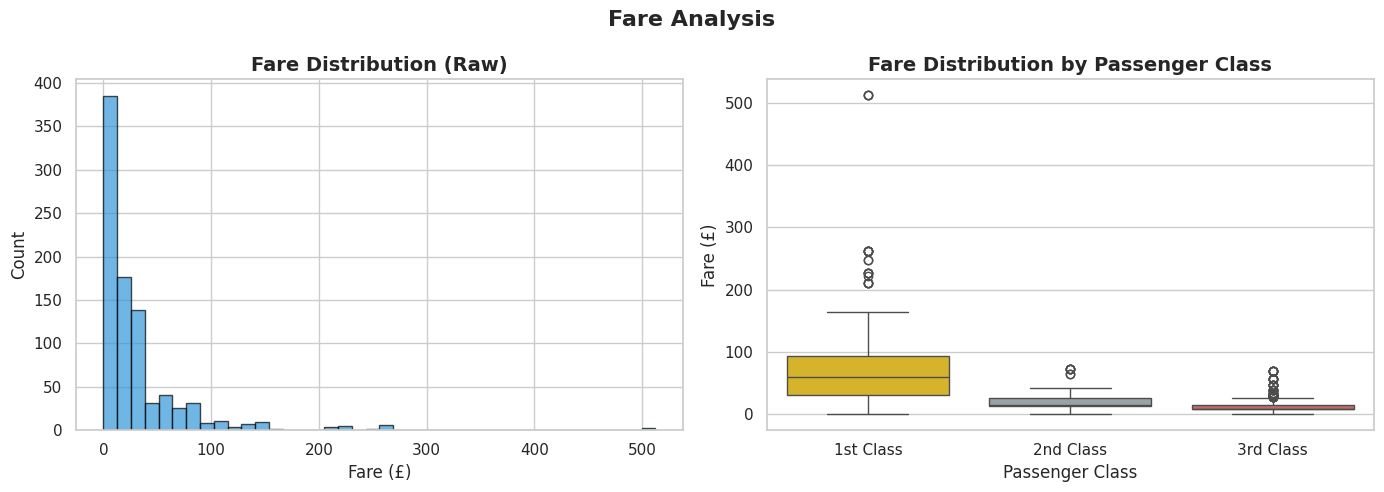


📌 Insight: Fare is heavily right-skewed — most paid little,
   but a few 1st class passengers paid enormously more.


In [ ]:
# ============================================================
# PLOT 6: FARE ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Fare histogram ---
ax1 = axes[0]
df['Fare'].plot(kind='hist', bins=40, color='#3498db',
                edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_title('Fare Distribution (Raw)')
ax1.set_xlabel('Fare (£)')
ax1.set_ylabel('Count')

# --- Right: Boxplot by class ---
ax2 = axes[1]
sns.boxplot(x='Pclass', y='Fare', data=df,
            palette=['#f1c40f', '#95a5a6', '#cd6155'], ax=ax2)
ax2.set_title('Fare Distribution by Passenger Class')
ax2.set_xlabel('Passenger Class')
ax2.set_ylabel('Fare (£)')
ax2.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.suptitle('Fare Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_fare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Insight: Fare is heavily right-skewed — most paid little,")
print("   but a few 1st class passengers paid enormously more.")

---
### 🔍 EDA Summary — Key Findings

| Feature | Finding | Impact on Model |
|---|---|---|
| **Gender** | Females: 74% survival, Males: 19% | Strongest predictor |
| **Pclass** | 1st: 63%, 2nd: 47%, 3rd: 24% | Strong predictor |
| **Age** | Children had higher survival | Moderate predictor |
| **Fare** | Higher fare → higher survival | Correlated with class |
| **Missing** | Cabin 77%, Age 20%, Embarked 0.2% | Needs careful handling |
| **Imbalance** | 61.6% vs 38.4% | Use F1-score, not just accuracy |

---
## 🧹 Section 4: Data Cleaning & Feature Engineering
> Handling missing values intelligently, removing noise, and creating new meaningful features that improve model performance. This is where real Data Science happens.

In [ ]:
# ============================================================
# WORKING COPY — NEVER MODIFY ORIGINAL
# ============================================================

df_clean = df.copy()

print(f"✅ Working copy created.")
print(f"   Original df    : {df.shape}")
print(f"   Working df_clean: {df_clean.shape}")

✅ Working copy created.
   Original df    : (891, 12)
   Working df_clean: (891, 12)


In [ ]:
# ============================================================
# FEATURE 1: EXTRACT TITLE FROM NAME
# ============================================================

# Extract title using regex
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("Raw titles found:")
print(df_clean['Title'].value_counts())

Raw titles found:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [ ]:
# ============================================================
# GROUP RARE TITLES INTO CATEGORIES
# ============================================================

# Map rare/unusual titles into 4 clean categories
title_mapping = {
    'Mr'    : 'Mr',
    'Miss'  : 'Miss',
    'Mrs'   : 'Mrs',
    'Master': 'Master',       # Young boys
    'Dr'    : 'Officer',
    'Rev'   : 'Officer',
    'Col'   : 'Officer',
    'Major' : 'Officer',
    'Capt'  : 'Officer',
    'Lady'  : 'Royalty',
    'Countess': 'Royalty',
    'Don'   : 'Royalty',
    'Sir'   : 'Royalty',
    'Jonkheer': 'Royalty',
    'Dona'  : 'Royalty',
    'Mlle'  : 'Miss',         # French equivalent of Miss
    'Ms'    : 'Miss',
    'Mme'   : 'Mrs',          # French equivalent of Mrs
}

df_clean['Title'] = df_clean['Title'].map(title_mapping)

# Fill any unmapped titles with 'Other'
df_clean['Title'].fillna('Other', inplace=True)

print("Cleaned title distribution:")
print(df_clean['Title'].value_counts())
print()

# Survival rate by title — powerful insight
print("Survival rate by title:")
print(df_clean.groupby('Title')['Survived'].mean().round(3).sort_values(ascending=False))

Cleaned title distribution:
Title
Mr         517
Miss       185
Mrs        126
Master      40
Officer     18
Royalty      5
Name: count, dtype: int64

Survival rate by title:
Title
Mrs        0.794
Miss       0.703
Royalty    0.600
Master     0.575
Officer    0.278
Mr         0.157
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# FEATURE 2: FAMILY SIZE
# ============================================================

# Combine SibSp (siblings/spouses) and Parch (parents/children)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1  # +1 = themselves

print("Family size distribution:")
print(df_clean['FamilySize'].value_counts().sort_index())
print()
print("Survival rate by family size:")
print(df_clean.groupby('FamilySize')['Survived'].mean().round(3))

Family size distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Survival rate by family size:
FamilySize
1     0.304
2     0.553
3     0.578
4     0.724
5     0.200
6     0.136
7     0.333
8     0.000
11    0.000
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# FEATURE 3: IS ALONE
# ============================================================

df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print("Travelling alone distribution:")
print(df_clean['IsAlone'].value_counts())
print()
print("Survival rate — Alone vs With Family:")
print(df_clean.groupby('IsAlone')['Survived'].mean().round(3))

Travelling alone distribution:
IsAlone
1    537
0    354
Name: count, dtype: int64

Survival rate — Alone vs With Family:
IsAlone
0    0.506
1    0.304
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# FEATURE 4: HAS CABIN (from 77% missing Cabin column)
# ============================================================

df_clean['HasCabin'] = df_clean['Cabin'].notnull().astype(int)

print("Has cabin distribution:")
print(df_clean['HasCabin'].value_counts())
print()
print("Survival rate — Has Cabin vs No Cabin:")
print(df_clean.groupby('HasCabin')['Survived'].mean().round(3))

Has cabin distribution:
HasCabin
0    687
1    204
Name: count, dtype: int64

Survival rate — Has Cabin vs No Cabin:
HasCabin
0    0.300
1    0.667
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# FEATURE 5: FARE BANDS (Binning continuous → categorical)
# ============================================================

df_clean['FareBand'] = pd.qcut(df_clean['Fare'], q=4,
                                labels=['Low', 'Mid', 'High', 'Very High'])

print("Fare band distribution:")
print(df_clean['FareBand'].value_counts().sort_index())
print()
print("Survival rate by fare band:")
print(df_clean.groupby('FareBand')['Survived'].mean().round(3))

Fare band distribution:
FareBand
Low          223
Mid          224
High         222
Very High    222
Name: count, dtype: int64

Survival rate by fare band:
FareBand
Low          0.197
Mid          0.304
High         0.455
Very High    0.581
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# MISSING VALUE 1: AGE (177 missing — 20%)
# ============================================================

print("Before — Age missing:", df_clean['Age'].isnull().sum())

# Strategy: Fill with MEDIAN age grouped by Title
# Because a Master (young boy) has very different age than a Mr (adult male)
age_medians = df_clean.groupby('Title')['Age'].median()
print("\nMedian age by title:")
print(age_medians)

def fill_age(row):
    if pd.isnull(row['Age']):
        return age_medians[row['Title']]
    return row['Age']

df_clean['Age'] = df_clean.apply(fill_age, axis=1)

print(f"\nAfter — Age missing: {df_clean['Age'].isnull().sum()}")
print("✅ Age imputed using title-grouped medians")

Before — Age missing: 177

Median age by title:
Title
Master      3.5
Miss       21.0
Mr         30.0
Mrs        35.0
Officer    50.0
Royalty    40.0
Name: Age, dtype: float64

After — Age missing: 0
✅ Age imputed using title-grouped medians


In [ ]:
# ============================================================
# MISSING VALUE 2: EMBARKED (2 missing)
# MISSING VALUE 3: FARE (check if any missing)
# ============================================================

# Embarked — fill with mode (most common port)
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(embarked_mode, inplace=True)
print(f"✅ Embarked filled with mode: '{embarked_mode}'")
print(f"   Embarked missing: {df_clean['Embarked'].isnull().sum()}")

# Fare — check and fill if needed
print(f"\n   Fare missing: {df_clean['Fare'].isnull().sum()}")
if df_clean['Fare'].isnull().sum() > 0:
    df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)
    print("✅ Fare filled with median")
else:
    print("✅ Fare has no missing values")

✅ Embarked filled with mode: 'S'
   Embarked missing: 0

   Fare missing: 0
✅ Fare has no missing values


In [ ]:
# ============================================================
# FEATURE 6: AGE BANDS (after filling missing ages)
# ============================================================

df_clean['AgeBand'] = pd.cut(df_clean['Age'],
                              bins=[0, 12, 18, 35, 60, 100],
                              labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

print("Age band distribution:")
print(df_clean['AgeBand'].value_counts().sort_index())
print()
print("Survival rate by age band:")
print(df_clean.groupby('AgeBand')['Survived'].mean().round(3))

Age band distribution:
AgeBand
Child           73
Teen            70
Young Adult    530
Adult          196
Senior          22
Name: count, dtype: int64

Survival rate by age band:
AgeBand
Child          0.575
Teen           0.429
Young Adult    0.353
Adult          0.398
Senior         0.227
Name: Survived, dtype: float64


In [ ]:
# ============================================================
# DROP UNNECESSARY COLUMNS
# ============================================================

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

df_clean.drop(columns=cols_to_drop, inplace=True)

print("✅ Dropped columns:", cols_to_drop)
print(f"\nRemaining columns ({len(df_clean.columns)}):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:02d}. {col}")

✅ Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']

Remaining columns (14):
  01. Survived
  02. Pclass
  03. Sex
  04. Age
  05. SibSp
  06. Parch
  07. Fare
  08. Embarked
  09. Title
  10. FamilySize
  11. IsAlone
  12. HasCabin
  13. FareBand
  14. AgeBand


In [ ]:
# ============================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================

# Convert text categories to numbers for ML algorithms

# Sex: male=1, female=0
df_clean['Sex'] = df_clean['Sex'].map({'male': 1, 'female': 0})

# Embarked: S=0, C=1, Q=2
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Title: encode to numbers
title_mapping_num = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3,
                     'Officer': 4, 'Royalty': 5, 'Other': 6}
df_clean['Title'] = df_clean['Title'].map(title_mapping_num)

# AgeBand: encode ordinal
ageband_mapping = {'Child': 0, 'Teen': 1, 'Young Adult': 2,
                   'Adult': 3, 'Senior': 4}
df_clean['AgeBand'] = df_clean['AgeBand'].map(ageband_mapping)

# FareBand: encode ordinal
fareband_mapping = {'Low': 0, 'Mid': 1, 'High': 2, 'Very High': 3}
df_clean['FareBand'] = df_clean['FareBand'].map(fareband_mapping)

print("✅ All categorical columns encoded")
print()
print("Data types after encoding:")
print(df_clean.dtypes)

✅ All categorical columns encoded

Data types after encoding:
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
Title            int64
FamilySize       int64
IsAlone          int64
HasCabin         int64
FareBand      category
AgeBand       category
dtype: object


In [ ]:
# ============================================================
# FINAL CLEANED DATASET CHECK
# ============================================================

print("=" * 60)
print("FINAL CLEANED DATASET")
print("=" * 60)
print(f"\nShape: {df_clean.shape}")
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")
print()
print("Sample rows:")
print(df_clean.head())
print()
print("Data types:")
print(df_clean.dtypes)

FINAL CLEANED DATASET

Shape: (891, 14)

Missing values remaining: 0

Sample rows:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  FamilySize  IsAlone  HasCabin FareBand AgeBand
0         0       3    1  22.0      1      0   7.2500         0      0           2        0         0        0       2
1         1       1    0  38.0      1      0  71.2833         1      2           2        0         1        3       3
2         1       3    0  26.0      0      0   7.9250         0      1           1        1         0        1       2
3         1       1    0  35.0      1      0  53.1000         0      2           2        0         1        3       2
4         0       3    1  35.0      0      0   8.0500         0      0           1        1         0        1       2

Data types:
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
Title 

---
### ✅ Data Cleaning & Feature Engineering Summary

**Missing Values Handled:**
- `Age` → Filled with title-grouped median (smarter than global median)
- `Embarked` → Filled with mode ('S')
- `Cabin` → Converted to binary `HasCabin` feature

**New Features Created:**
| Feature | Source | Insight |
|---|---|---|
| `Title` | Extracted from Name | Social status + gender signal |
| `FamilySize` | SibSp + Parch + 1 | Group survival dynamics |
| `IsAlone` | FamilySize == 1 | Solo travellers had lower survival |
| `HasCabin` | Cabin not null | Proxy for wealth/class |
| `AgeBand` | Age binned | Child/Teen/Adult/Senior groups |
| `FareBand` | Fare binned | Quartile-based wealth indicator |

**Columns Dropped:** PassengerId, Name, Ticket, Cabin


## 🎯 Section 5: Feature Selection & Model Training
>** Selecting the most relevant features, splitting data properly, and training multiple machine learning models to find the best performer.

In [ ]:
# ============================================================
# FEATURE SELECTION
# ============================================================

# Define features (X) and target (y)
# Drop Survived (target) and band columns we used only for insight
features_to_use = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
                   'Fare', 'Embarked', 'Title', 'FamilySize',
                   'IsAlone', 'HasCabin', 'AgeBand', 'FareBand']

X = df_clean[features_to_use]
y = df_clean['Survived']

print("=" * 60)
print("FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"\n✅ Features (X) shape : {X.shape}")
print(f"✅ Target  (y) shape : {y.shape}")
print(f"\nFeatures selected ({len(features_to_use)}):")
for i, feat in enumerate(features_to_use, 1):
    print(f"  {i:02d}. {feat}")
print(f"\nTarget distribution:")
print(y.value_counts())

FEATURE SELECTION SUMMARY

✅ Features (X) shape : (891, 13)
✅ Target  (y) shape : (891,)

Features selected (13):
  01. Pclass
  02. Sex
  03. Age
  04. SibSp
  05. Parch
  06. Fare
  07. Embarked
  08. Title
  09. FamilySize
  10. IsAlone
  11. HasCabin
  12. AgeBand
  13. FareBand

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
# ============================================================
# TRAIN - TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # reproducibility
    stratify=y             # maintain class balance in both splits
)

print("=" * 60)
print("TRAIN - TEST SPLIT")
print("=" * 60)
print(f"\n  Total dataset   : {X.shape[0]} passengers")
print(f"  Training set    : {X_train.shape[0]} passengers (80%)")
print(f"  Test set        : {X_test.shape[0]} passengers (20%)")
print()
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Class distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))

TRAIN - TEST SPLIT

  Total dataset   : 891 passengers
  Training set    : 712 passengers (80%)
  Test set        : 179 passengers (20%)

Class distribution in training set:
Survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Class distribution in test set:
Survived
0    0.615
1    0.385
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=" * 60)
print("FEATURE SCALING — StandardScaler")
print("=" * 60)
print()
print("Before scaling — Age column (first 5 values):")
print(X_train['Age'].values[:5])
print()
print("After scaling — Age column (first 5 values):")
print(X_train_scaled[:, X_train.columns.get_loc('Age')][:5].round(3))
print()
print("✅ Features scaled to mean=0, std=1")
print()
print("⚠️  Note: fit_transform on TRAIN only, transform on TEST only")

FEATURE SCALING — StandardScaler

Before scaling — Age column (first 5 values):
[30. 30. 30. 18. 31.]

After scaling — Age column (first 5 values):
[ 0.036  0.036  0.036 -0.869  0.111]

✅ Features scaled to mean=0, std=1

⚠️  Note: fit_transform on TRAIN only, transform on TEST only


---
### 🤖 Model Training — Four Classifiers

We train four different models to compare approaches:
- **Logistic Regression** — Linear baseline model
- **Decision Tree** — Interpretable rule-based model  
- **Random Forest** — Powerful ensemble method
- **K-Nearest Neighbors** — Distance-based model

In [ ]:
# ============================================================
# TRAIN ALL FOUR MODELS
# ============================================================

# --- 1. Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"✅ Logistic Regression trained  | Accuracy: {lr_acc:.4f}")

# --- 2. Decision Tree ---
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc  = accuracy_score(y_test, dt_pred)

print(f"✅ Decision Tree trained        | Accuracy: {dt_acc:.4f}")

# --- 3. Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"✅ Random Forest trained        | Accuracy: {rf_acc:.4f}")

# --- 4. K-Nearest Neighbors ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc  = accuracy_score(y_test, knn_pred)

print(f"✅ K-Nearest Neighbors trained  | Accuracy: {knn_acc:.4f}")

✅ Logistic Regression trained  | Accuracy: 0.8101
✅ Decision Tree trained        | Accuracy: 0.7821
✅ Random Forest trained        | Accuracy: 0.8045
✅ K-Nearest Neighbors trained  | Accuracy: 0.7933


---
### 📚 How Each Model Works

**Logistic Regression:**  
Despite the name, it's a classification algorithm. It calculates the probability of survival using a sigmoid function. It draws a straight decision boundary — simple, fast, interpretable.

**Decision Tree:**  
Asks a series of yes/no questions: "Is the passenger female? → Is their class 1st?" It builds a tree of rules from the data. Highly interpretable but prone to overfitting.

**Random Forest:**  
Builds 100 decision trees, each trained on a random subset of data and features. Final prediction = majority vote across all trees. More accurate and robust than a single tree.

**K-Nearest Neighbors:**  
For a new passenger, it finds the 5 most similar passengers in the training data and takes a majority vote of their survival. Simple concept but computationally slow on large datasets.

In [ ]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(name, y_true, y_pred):
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1 Score' : f1_score(y_true, y_pred)
    }

results = [
    evaluate_model('Logistic Regression', y_test, lr_pred),
    evaluate_model('Decision Tree',       y_test, dt_pred),
    evaluate_model('Random Forest',       y_test, rf_pred),
    evaluate_model('KNN',                 y_test, knn_pred),
]

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)

print("=" * 65)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 65)
print(results_df.to_string())
print()
print(f"🏆 Best Accuracy : {results_df['Accuracy'].idxmax()}")
print(f"🏆 Best F1 Score : {results_df['F1 Score'].idxmax()}")

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.8101     0.7536  0.7536    0.7536
Decision Tree          0.7821     0.8000  0.5797    0.6723
Random Forest          0.8045     0.7500  0.7391    0.7445
KNN                    0.7933     0.7353  0.7246    0.7299

🏆 Best Accuracy : Logistic Regression
🏆 Best F1 Score : Logistic Regression


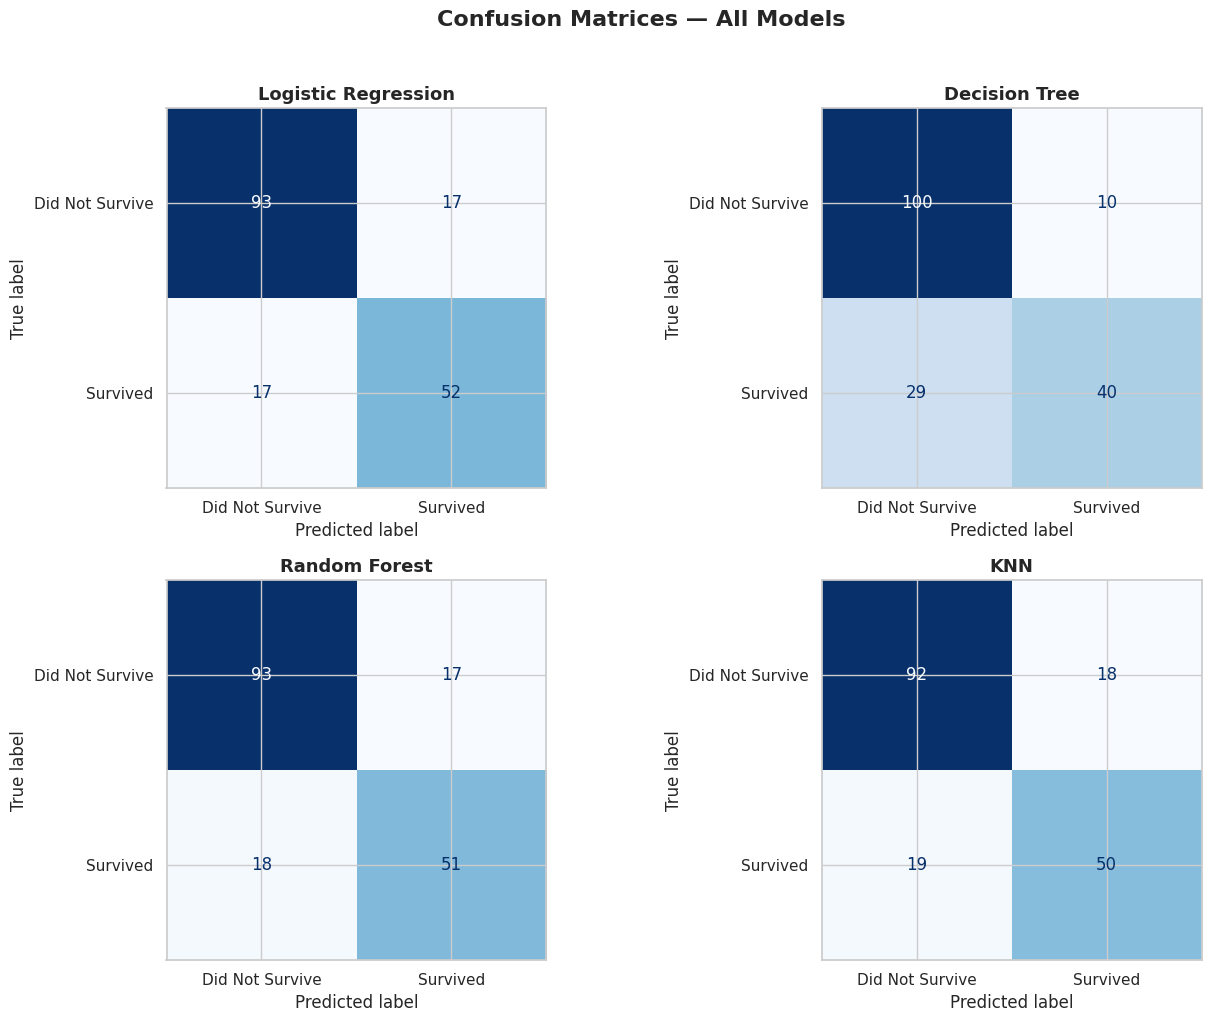

In [ ]:
# ============================================================
# CONFUSION MATRICES — ALL MODELS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree',       dt_pred),
    ('Random Forest',       rf_pred),
    ('KNN',                 knn_pred),
]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Did Not Survive', 'Survived'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=16,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================

model_list = [
    ('Logistic Regression', lr_pred),
    ('Decision Tree',       dt_pred),
    ('Random Forest',       rf_pred),
    ('KNN',                 knn_pred),
]

for name, pred in model_list:
    print("=" * 55)
    print(f"  {name}")
    print("=" * 55)
    print(classification_report(y_test, pred,
          target_names=['Did Not Survive', 'Survived']))

  Logistic Regression
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.85      0.85       110
       Survived       0.75      0.75      0.75        69

       accuracy                           0.81       179
      macro avg       0.80      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179

  Decision Tree
                 precision    recall  f1-score   support

Did Not Survive       0.78      0.91      0.84       110
       Survived       0.80      0.58      0.67        69

       accuracy                           0.78       179
      macro avg       0.79      0.74      0.75       179
   weighted avg       0.78      0.78      0.77       179

  Random Forest
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.85      0.84       110
       Survived       0.75      0.74      0.74        69

       accuracy                           0.80       179
      macro avg       0.79

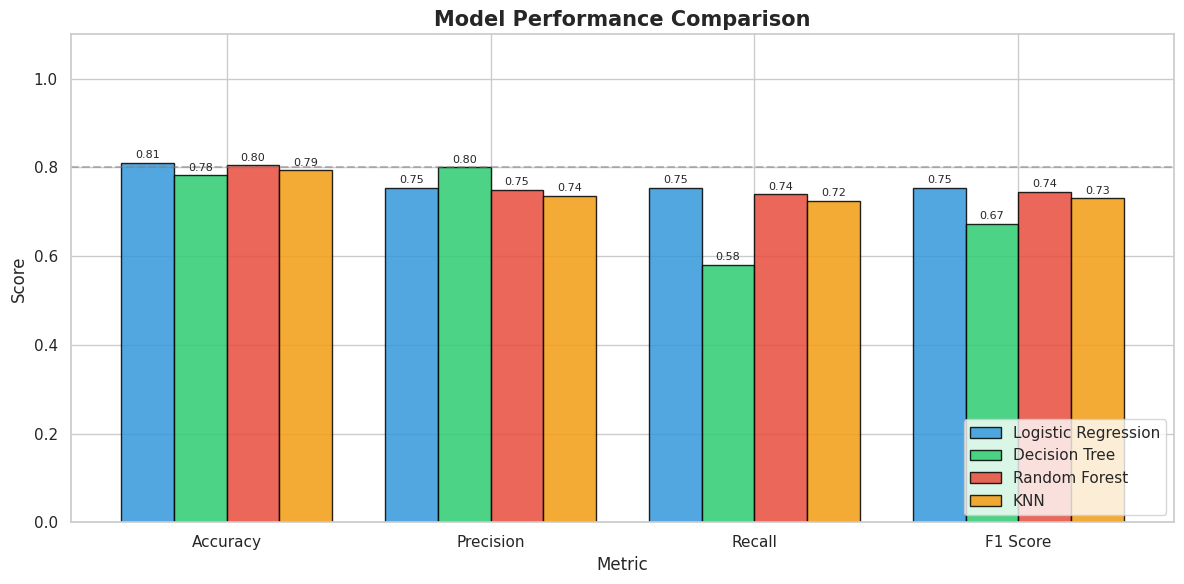

In [ ]:
# ============================================================
# VISUAL MODEL COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row[metrics].values,
           width, label=idx, color=colors[i],
           edgecolor='black', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('plot8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CROSS VALIDATION — MORE RELIABLE THAN SINGLE SPLIT
# ============================================================

print("=" * 60)
print("5-FOLD CROSS VALIDATION SCORES")
print("=" * 60)

cv_models = [
    ('Logistic Regression', lr_model, X_train_scaled),
    ('Decision Tree',       dt_model, X_train),
    ('Random Forest',       rf_model, X_train),
    ('KNN',                 knn_model, X_train_scaled),
]

for name, model, X_data in cv_models:
    cv_scores = cross_val_score(model, X_data, y_train,
                                cv=5, scoring='accuracy')
    print(f"\n  {name}")
    print(f"  Scores : {cv_scores.round(4)}")
    print(f"  Mean   : {cv_scores.mean():.4f}")
    print(f"  Std    : {cv_scores.std():.4f}  "
          f"{'✅ Stable' if cv_scores.std() < 0.03 else '⚠️ Unstable'}")

5-FOLD CROSS VALIDATION SCORES

  Logistic Regression
  Scores : [0.7972 0.7832 0.8239 0.8239 0.8099]
  Mean   : 0.8076
  Std    : 0.0158  ✅ Stable

  Decision Tree
  Scores : [0.7832 0.7552 0.8239 0.838  0.7606]
  Mean   : 0.7922
  Std    : 0.0333  ⚠️ Unstable

  Random Forest
  Scores : [0.7692 0.7483 0.7958 0.8451 0.7958]
  Mean   : 0.7908
  Std    : 0.0325  ⚠️ Unstable

  KNN
  Scores : [0.7692 0.8182 0.8239 0.8099 0.8169]
  Mean   : 0.8076
  Std    : 0.0197  ✅ Stable


---
## ⚙️ Section 6: Hyperparameter Tuning
> Using GridSearchCV to systematically find the optimal model parameters. This is how real Data Scientists move beyond default model settings.

---
### 📚 Parameters vs Hyperparameters

**Parameters** — values the model *learns* from data during training  
(e.g. the weights in Logistic Regression)

**Hyperparameters** — settings *you choose* before training begins  
(e.g. how deep a tree can grow, how many trees in the forest)

Choosing good hyperparameters manually is guesswork.  
**GridSearchCV** automates this — it tries every combination and finds the best.

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING — RANDOM FOREST (GridSearchCV)
# ============================================================

print("⏳ Running GridSearchCV — this may take 1-2 minutes...")
print("   Trying every combination of parameters systematically...\n")

# Define parameter grid to search
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

# Calculate total combinations
total = 1
for v in param_grid.values():
    total *= len(v)
print(f"   Total combinations to try: {total}")
print(f"   With 5-fold CV: {total * 5} model fits\n")

# Run GridSearchCV
rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator  = rf_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',          # optimise for F1, not just accuracy
    n_jobs     = -1,            # use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV complete!")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:20s}: {value}")
print(f"\n🏆 Best CV F1 Score: {grid_search.best_score_:.4f}")

⏳ Running GridSearchCV — this may take 1-2 minutes...
   Trying every combination of parameters systematically...

   Total combinations to try: 270
   With 5-fold CV: 1350 model fits

Fitting 5 folds for each of 270 candidates, totalling 1350 fits

✅ GridSearchCV complete!

🏆 Best Parameters:
   max_depth           : 4
   max_features        : sqrt
   min_samples_leaf    : 2
   min_samples_split   : 10
   n_estimators        : 100

🏆 Best CV F1 Score: 0.7733


In [ ]:
# ============================================================
# EVALUATE TUNED RANDOM FOREST
# ============================================================

# Get the best model directly from grid search
best_rf = grid_search.best_estimator_

# Predict on test set
best_rf_pred = best_rf.predict(X_test)
best_rf_acc  = accuracy_score(y_test, best_rf_pred)
best_rf_f1   = f1_score(y_test, best_rf_pred)

print("=" * 60)
print("TUNED RANDOM FOREST — TEST SET PERFORMANCE")
print("=" * 60)
print(f"\n  Accuracy  : {best_rf_acc:.4f}")
print(f"  F1 Score  : {best_rf_f1:.4f}")
print()
print("  Improvement over default Random Forest:")
print(f"  Accuracy  : {rf_acc:.4f} → {best_rf_acc:.4f}  "
      f"({'+' if best_rf_acc >= rf_acc else ''}"
      f"{(best_rf_acc - rf_acc)*100:.2f}%)")
print(f"  F1 Score  : {f1_score(y_test, rf_pred):.4f} → {best_rf_f1:.4f}  "
      f"({'+' if best_rf_f1 >= f1_score(y_test, rf_pred) else ''}"
      f"{(best_rf_f1 - f1_score(y_test, rf_pred))*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, best_rf_pred,
      target_names=['Did Not Survive', 'Survived']))

TUNED RANDOM FOREST — TEST SET PERFORMANCE

  Accuracy  : 0.8268
  F1 Score  : 0.7669

  Improvement over default Random Forest:
  Accuracy  : 0.8045 → 0.8268  (+2.23%)
  F1 Score  : 0.7445 → 0.7669  (+2.24%)

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.84      0.88      0.86       110
       Survived       0.80      0.74      0.77        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.81       179
   weighted avg       0.83      0.83      0.83       179



FEATURE IMPORTANCE RANKING
   Feature  Importance
     Title    0.272960
       Sex    0.249554
      Fare    0.098117
  HasCabin    0.084537
    Pclass    0.082652
       Age    0.055186
FamilySize    0.049411
  FareBand    0.027317
     SibSp    0.022325
   AgeBand    0.018557
  Embarked    0.017628
     Parch    0.011428
   IsAlone    0.010329


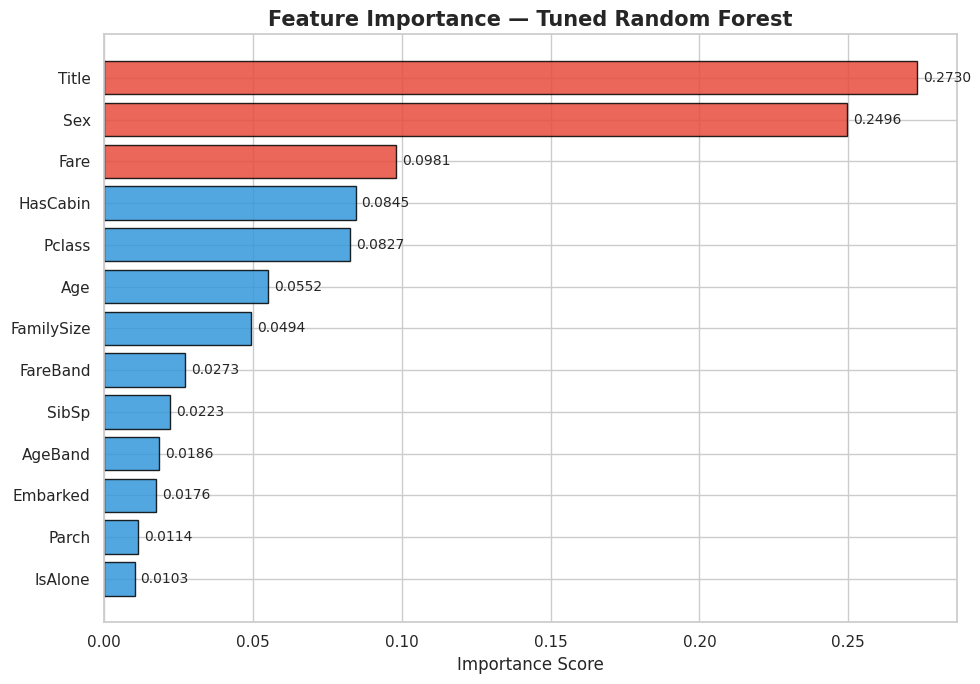


📌 Top 3 most important features highlighted in red


In [ ]:
# ============================================================
# FEATURE IMPORTANCE — WHAT DID THE MODEL LEARN?
# ============================================================

feature_importance = pd.DataFrame({
    'Feature'   : features_to_use,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 45)
print("FEATURE IMPORTANCE RANKING")
print("=" * 45)
print(feature_importance.to_string(index=False))

# --- Visualize ---
plt.figure(figsize=(10, 7))

colors_imp = ['#e74c3c' if i < 3 else '#3498db'
              for i in range(len(feature_importance))]

bars = plt.barh(feature_importance['Feature'],
                feature_importance['Importance'],
                color=colors_imp, edgecolor='black', alpha=0.85)

plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Tuned Random Forest',
          fontsize=15, fontweight='bold')
plt.gca().invert_yaxis()

for bar, val in zip(bars, feature_importance['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Top 3 most important features highlighted in red")

In [ ]:
# ============================================================
# OVERFITTING CHECK
# ============================================================

print("=" * 60)
print("OVERFITTING ANALYSIS")
print("=" * 60)

models_check = [
    ('Logistic Regression', lr_model,  X_train_scaled, X_test_scaled),
    ('Decision Tree',       dt_model,  X_train,        X_test),
    ('Random Forest',       rf_model,  X_train,        X_test),
    ('Tuned Random Forest', best_rf,   X_train,        X_test),
    ('KNN',                 knn_model, X_train_scaled, X_test_scaled),
]

print(f"\n  {'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Status':>12}")
print("  " + "-" * 70)

for name, model, X_tr, X_te in models_check:
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    gap       = train_acc - test_acc

    if gap > 0.08:
        status = "⚠️ Overfit"
    elif test_acc < 0.75:
        status = "⚠️ Underfit"
    else:
        status = "✅ Good"

    print(f"  {name:<25} {train_acc:>10.4f} {test_acc:>10.4f} "
          f"{gap:>8.4f} {status:>12}")

OVERFITTING ANALYSIS

  Model                      Train Acc   Test Acc      Gap       Status
  ----------------------------------------------------------------------
  Logistic Regression           0.8230     0.8101   0.0130       ✅ Good
  Decision Tree                 0.8708     0.7821   0.0887   ⚠️ Overfit
  Random Forest                 0.9874     0.8045   0.1829   ⚠️ Overfit
  Tuned Random Forest           0.8413     0.8268   0.0145       ✅ Good
  KNN                           0.8596     0.7933   0.0663       ✅ Good


In [ ]:
# ============================================================
# FINAL MODEL SELECTION SUMMARY
# ============================================================

print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)

all_results = {
    'Logistic Regression'  : accuracy_score(y_test, lr_pred),
    'Decision Tree'        : accuracy_score(y_test, dt_pred),
    'Random Forest'        : accuracy_score(y_test, rf_pred),
    'KNN'                  : accuracy_score(y_test, knn_pred),
    'Tuned Random Forest'  : best_rf_acc,
}

for name, acc in sorted(all_results.items(),
                         key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f"  {name:<25} {acc:.4f}  {bar}")

print(f"\n🏆 Selected Model: Tuned Random Forest")
print(f"   Final Test Accuracy : {best_rf_acc:.4f}")
print(f"   Final F1 Score      : {best_rf_f1:.4f}")
print(f"\n✅ Model ready for prediction and deployment")

FINAL MODEL SELECTION
  Tuned Random Forest       0.8268  █████████████████████████████████
  Logistic Regression       0.8101  ████████████████████████████████
  Random Forest             0.8045  ████████████████████████████████
  KNN                       0.7933  ███████████████████████████████
  Decision Tree             0.7821  ███████████████████████████████

🏆 Selected Model: Tuned Random Forest
   Final Test Accuracy : 0.8268
   Final F1 Score      : 0.7669

✅ Model ready for prediction and deployment


In [ ]:
# ============================================================
# MANUAL PREDICTION SYSTEM
# ============================================================

def predict_survival(pclass, sex, age, sibsp, parch, fare,
                     embarked, title, family_size,
                     is_alone, has_cabin):
    """
    Predicts survival for a single passenger.

    Parameters:
    -----------
    pclass      : int   — 1, 2, or 3
    sex         : str   — 'male' or 'female'
    age         : float — passenger age
    sibsp       : int   — siblings/spouses aboard
    parch       : int   — parents/children aboard
    fare        : float — ticket fare paid
    embarked    : str   — 'S', 'C', or 'Q'
    title       : str   — 'Mr','Miss','Mrs','Master','Officer','Royalty'
    family_size : int   — total family members including self
    is_alone    : int   — 1 if travelling alone, 0 otherwise
    has_cabin   : int   — 1 if had cabin, 0 otherwise
    """

    # Encode inputs
    sex_enc      = 1 if sex == 'male' else 0
    embarked_enc = {'S': 0, 'C': 1, 'Q': 2}.get(embarked, 0)
    title_enc    = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3,
                    'Officer': 4, 'Royalty': 5, 'Other': 6}.get(title, 0)

    # Age band
    if age <= 12:   age_band = 0
    elif age <= 18: age_band = 1
    elif age <= 35: age_band = 2
    elif age <= 60: age_band = 3
    else:           age_band = 4

    # Fare band
    if fare <= 7.9:    fare_band = 0
    elif fare <= 14.4: fare_band = 1
    elif fare <= 31.0: fare_band = 2
    else:              fare_band = 3

    # Build input array
    passenger = np.array([[pclass, sex_enc, age, sibsp, parch,
                           fare, embarked_enc, title_enc,
                           family_size, is_alone, has_cabin,
                           age_band, fare_band]])

    # Predict
    prediction    = best_rf.predict(passenger)[0]
    probability   = best_rf.predict_proba(passenger)[0]

    # Display result
    print("=" * 50)
    print("  🚢 TITANIC SURVIVAL PREDICTION")
    print("=" * 50)
    print(f"  Passenger Details:")
    print(f"    Class     : {pclass}{'st' if pclass==1 else 'nd' if pclass==2 else 'rd'}")
    print(f"    Sex       : {sex.capitalize()}")
    print(f"    Age       : {age}")
    print(f"    Title     : {title}")
    print(f"    Fare      : £{fare}")
    print(f"    Family    : {family_size} member(s)")
    print()
    print(f"  Survival Probability  : {probability[1]*100:.1f}%")
    print(f"  Non-Survival Prob     : {probability[0]*100:.1f}%")
    print()

    if prediction == 1:
        print("  🟢 PREDICTION: SURVIVED")
    else:
        print("  🔴 PREDICTION: DID NOT SURVIVE")
    print("=" * 50)

    return prediction, probability

In [ ]:
# ============================================================
# TEST PREDICTIONS — FAMOUS PASSENGER PROFILES
# ============================================================

print("TEST 1 — Upper class woman (high survival expected)")
print()
predict_survival(
    pclass=1, sex='female', age=29, sibsp=0, parch=0,
    fare=211.0, embarked='S', title='Mrs',
    family_size=1, is_alone=1, has_cabin=1
)

print()
print("TEST 2 — 3rd class young man (low survival expected)")
print()
predict_survival(
    pclass=3, sex='male', age=22, sibsp=1, parch=0,
    fare=7.25, embarked='S', title='Mr',
    family_size=2, is_alone=0, has_cabin=0
)

print()
print("TEST 3 — Young child in 2nd class")
print()
predict_survival(
    pclass=2, sex='male', age=8, sibsp=1, parch=2,
    fare=26.0, embarked='S', title='Master',
    family_size=4, is_alone=0, has_cabin=0
)

TEST 1 — Upper class woman (high survival expected)

  🚢 TITANIC SURVIVAL PREDICTION
  Passenger Details:
    Class     : 1st
    Sex       : Female
    Age       : 29
    Title     : Mrs
    Fare      : £211.0
    Family    : 1 member(s)

  Survival Probability  : 92.8%
  Non-Survival Prob     : 7.2%

  🟢 PREDICTION: SURVIVED

TEST 2 — 3rd class young man (low survival expected)

  🚢 TITANIC SURVIVAL PREDICTION
  Passenger Details:
    Class     : 3rd
    Sex       : Male
    Age       : 22
    Title     : Mr
    Fare      : £7.25
    Family    : 2 member(s)

  Survival Probability  : 12.7%
  Non-Survival Prob     : 87.3%

  🔴 PREDICTION: DID NOT SURVIVE

TEST 3 — Young child in 2nd class

  🚢 TITANIC SURVIVAL PREDICTION
  Passenger Details:
    Class     : 2nd
    Sex       : Male
    Age       : 8
    Title     : Master
    Fare      : £26.0
    Family    : 4 member(s)

  Survival Probability  : 60.5%
  Non-Survival Prob     : 39.5%

  🟢 PREDICTION: SURVIVED


(np.int64(1), array([0.39450136, 0.60549864]))

In [ ]:
# ============================================================
# SAVE MODEL WITH PICKLE
# ============================================================

import pickle

# Save the trained model
with open('titanic_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

# Save the feature list
with open('titanic_features.pkl', 'wb') as f:
    pickle.dump(features_to_use, f)

print("✅ Model saved as  : titanic_model.pkl")
print("✅ Features saved  : titanic_features.pkl")
print()

# Verify it loads correctly
with open('titanic_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test)
test_acc  = accuracy_score(y_test, test_pred)
print(f"✅ Model reloaded and verified")
print(f"   Accuracy after reload: {test_acc:.4f} (should match original)")
print()
print("💡 Why save the model?")
print("   In production, you train ONCE and deploy.")
print("   The saved .pkl file is loaded by your web app,")
print("   API, or service — no retraining needed each time.")

✅ Model saved as  : titanic_model.pkl
✅ Features saved  : titanic_features.pkl

✅ Model reloaded and verified
   Accuracy after reload: 0.8268 (should match original)

💡 Why save the model?
   In production, you train ONCE and deploy.
   The saved .pkl file is loaded by your web app,
   API, or service — no retraining needed each time.


In [ ]:
from google.colab import files
files.download('titanic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>